# MCDI504 · Machine Learning I

## Formativa 3 - Fase 3: Clasificación Supervisada

**Grupo 7:** Alana Bermúdez, Gonzalo Mansilla y Eduardo Villalón

**Dataset:** Iris

**Objetivo:** Clasificar la especie de una flor Iris utilizando variables morfológicas del conjunto de datos.

**Modelos:** K-Nearest Neighbors (KNN), Árbol de Decisión, Support Vector Machine (SVM) y Naïve Bayes.

Este notebook corresponde a la continuidad del proyecto desarrollado en las fases anteriores utilizando el dataset Iris. En esta etapa el enfoque cambia desde un problema de regresión a un problema de clasificación supervisada.

La variable objetivo corresponde a la especie de la flor (`especie_codigo`), mientras que las variables predictoras utilizadas son:

- largo_sepalo_cm
- ancho_sepalo_cm
- largo_petalo_cm
- ancho_petalo_cm

Todos los modelos se entrenan utilizando la misma partición. El conjunto de entrenamiento corresponde a los datos con que el modelo aprende y el conjunto de prueba a observaciones reservadas para comprobar su comportamiento en datos no utilizados durante el ajuste. La comparación considera accuracy, precision, recall, F1 y matriz de confusión.

## 1. Configuración reproducible

Se fijan semillas, se registran versiones y se crean carpetas de salida. El dataset se carga desde `scikit-learn`, por lo que no requiere descarga manual.

In [1]:
from pathlib import Path
import sys, platform, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos de clasificación
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Métricas
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

sns.set_theme(
    style='whitegrid',
    palette='colorblind'
)

ROOT = Path.cwd()

FIG_DIR = ROOT / '05_Figuras'
RES_DIR = ROOT / '06_Resultados'

FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

print(f'Python: {sys.version.split()[0]}')
print(f'pandas: {pd.__version__} | numpy: {np.__version__} | scikit-learn: {sklearn.__version__}')
print(f'Plataforma: {platform.platform()}')
print(f'Semilla: {SEED}')

Python: 3.12.13
pandas: 2.2.3 | numpy: 2.3.5 | scikit-learn: 1.8.0
Plataforma: Linux-6.18.35-x86_64-with-glibc2.39
Semilla: 42


## 2. Carga, diccionario y validación del dataset

Iris contiene 150 observaciones y cuatro medidas morfológicas continuas. Para esta fase se conserva el mismo conjunto de datos y se redefine el objetivo analítico como un problema de clasificación supervisada orientado a predecir la especie de una flor Iris a partir de sus características morfológicas.

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={
    'sepal length (cm)': 'largo_sepalo_cm',
    'sepal width (cm)': 'ancho_sepalo_cm',
    'petal length (cm)': 'largo_petalo_cm',
    'petal width (cm)': 'ancho_petalo_cm',
    'target': 'especie_codigo'
})
df['especie'] = df['especie_codigo'].map(dict(enumerate(iris.target_names)))

print('Dimensión:', df.shape)
display(df.head())
display(pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'unicos': df.nunique()
}))
print('Duplicados exactos de medidas y especie:', df.duplicated().sum())

Dimensión: (150, 6)
Duplicados exactos de medidas y especie: 1


   largo_sepalo_cm  ancho_sepalo_cm  ...  especie_codigo  especie
0              5.1              3.5  ...               0   setosa
1              4.9              3.0  ...               0   setosa
2              4.7              3.2  ...               0   setosa
3              4.6              3.1  ...               0   setosa
4              5.0              3.6  ...               0   setosa

[5 rows x 6 columns]

                    tipo  nulos  unicos
largo_sepalo_cm  float64      0      35
ancho_sepalo_cm  float64      0      23
largo_petalo_cm  float64      0      43
ancho_petalo_cm  float64      0      22
especie_codigo     int64      0       3
especie           object      0       3

In [3]:
assert df.shape == (150, 6)
assert df.isna().sum().sum() == 0
assert set(df['especie']) == {'setosa', 'versicolor', 'virginica'}
assert (df[['largo_sepalo_cm','ancho_sepalo_cm','largo_petalo_cm','ancho_petalo_cm']] > 0).all().all()
print('✅ Validaciones estructurales y de dominio superadas.')

✅ Validaciones estructurales y de dominio superadas.


### Decisiones de calidad

- No existen valores faltantes, por lo que no se aplica imputación ni eliminación de filas.
- Se detecta una combinación repetida de mediciones y especie. Se conserva porque el dataset no posee un identificador individual y una coincidencia morfológica puede corresponder a flores diferentes; eliminarla sin evidencia alteraría la distribución.
- La variable objetivo corresponde a especie_codigo.
- `especie` se usa solo para el análisis descriptivo y para estratificar la partición.
- Las variables predictoras utilizadas para el modelamiento son:

  - largo_sepalo_cm
  - ancho_sepalo_cm
  - largo_petalo_cm
  - ancho_petalo_cm


## 3. Análisis exploratorio inicial

In [4]:
resumen = df.groupby('especie')[['largo_petalo_cm','ancho_petalo_cm']].agg(['count','mean','std','min','max']).round(3)
display(resumen)
resumen.to_csv(RES_DIR / 'resumen_por_especie.csv', encoding='utf-8-sig')

corr = df[['largo_petalo_cm','ancho_petalo_cm']].corr().iloc[0,1]
print(f'Correlación de Pearson largo–ancho del pétalo: {corr:.4f}')

Correlación de Pearson largo–ancho del pétalo: 0.9629


           largo_petalo_cm                     ... ancho_petalo_cm                 
                     count   mean    std  min  ...            mean    std  min  max
especie                                        ...                                 
setosa                  50  1.462  0.174  1.0  ...           0.246  0.105  0.1  0.6
versicolor              50  4.260  0.470  3.0  ...           1.326  0.198  1.0  1.8
virginica               50  5.552  0.552  4.5  ...           2.026  0.275  1.4  2.5

[3 rows x 10 columns]

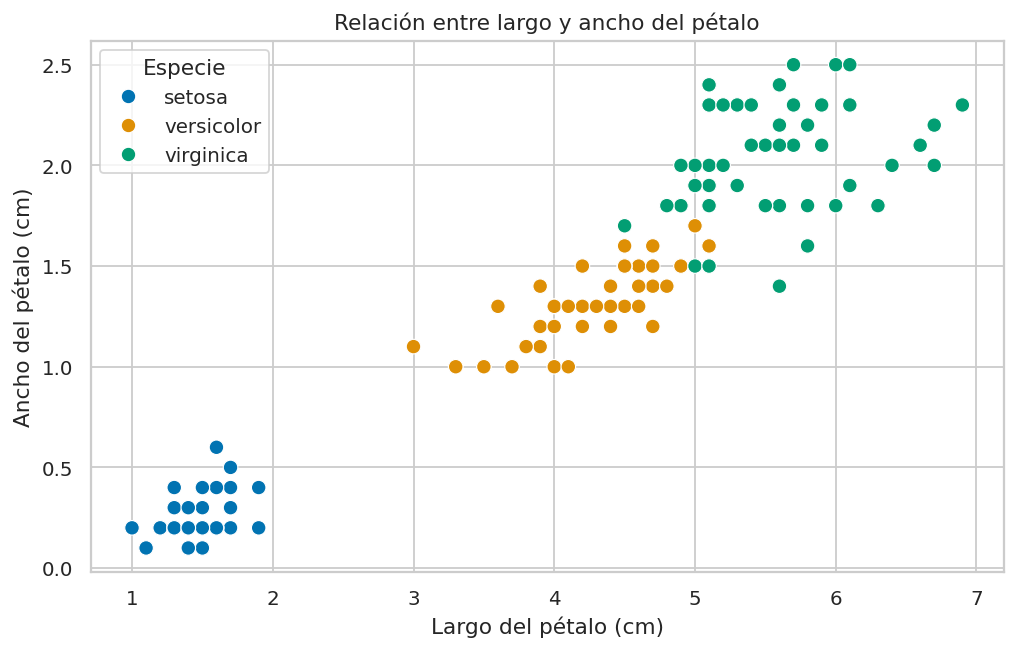

In [5]:
fig, ax = plt.subplots(figsize=(8,5.2))
sns.scatterplot(data=df, x='largo_petalo_cm', y='ancho_petalo_cm', hue='especie', s=65, ax=ax)
ax.set(title='Relación entre largo y ancho del pétalo', xlabel='Largo del pétalo (cm)', ylabel='Ancho del pétalo (cm)')
ax.legend(title='Especie')
fig.tight_layout(); fig.savefig(FIG_DIR/'figura_1_relacion_petalo.png', dpi=220, bbox_inches='tight'); plt.show()

**Interpretación.**
El gráfico evidencia una clara diferenciación entre las especies del dataset Iris.

Las observaciones forman agrupaciones relativamente separadas, lo que sugiere que las características morfológicas del sépalo y del pétalo contienen información suficiente para construir modelos de clasificación supervisada capaces de identificar correctamente cada especie.

## 4. Preparación analítica y partición entrenamiento/prueba

In [6]:
X = df[['largo_sepalo_cm',
        'ancho_sepalo_cm',
        'largo_petalo_cm',
        'ancho_petalo_cm']]

y = df['especie_codigo']

estratos = df['especie_codigo']

X_train, X_test, y_train, y_test, estratos_train, estratos_test = train_test_split(
    X, y, estratos, test_size=0.20, random_state=SEED, stratify=estratos
)

particion = pd.DataFrame({
    'Conjunto':['Entrenamiento','Prueba'],
    'Filas':[len(X_train),len(X_test)],
    'Porcentaje':[len(X_train)/len(X)*100,len(X_test)/len(X)*100]
})
display(particion)
print('Especies en prueba:', estratos_test.value_counts().sort_index().to_dict())

assert len(X_train)==120 and len(X_test)==30
assert estratos_test.value_counts().sort_index().tolist()==[10,10,10]
assert X_train.index.intersection(X_test.index).empty
print('✅ Partición reproducible, disjunta y representativa.')

Especies en prueba: {0: 10, 1: 10, 2: 10}
✅ Partición reproducible, disjunta y representativa.


        Conjunto  Filas  Porcentaje
0  Entrenamiento    120        80.0
1         Prueba     30        20.0

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

display(X_train.head())

X_train: (120, 4)
X_test: (30, 4)


     largo_sepalo_cm  ancho_sepalo_cm  largo_petalo_cm  ancho_petalo_cm
8                4.4              2.9              1.4              0.2
106              4.9              2.5              4.5              1.7
76               6.8              2.8              4.8              1.4
9                4.9              3.1              1.5              0.1
89               5.5              2.5              4.0              1.3

# 5. Modelos de Clasificación Tradicionales y su Evaluación

## 5.1 K-Nearest Neighbors (KNN)

El algoritmo K-Nearest Neighbors (KNN) clasifica observaciones en función de los vecinos más cercanos en el espacio de características. En esta aplicación se utiliza para predecir la especie de una flor Iris a partir de sus medidas morfológicas.

Accuracy KNN: 0.9333
Precision macro KNN: 0.9444
Recall macro KNN: 0.9333
F1 macro KNN: 0.9327

Matriz de confusión:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8333    1.0000    0.9091        10
   virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30



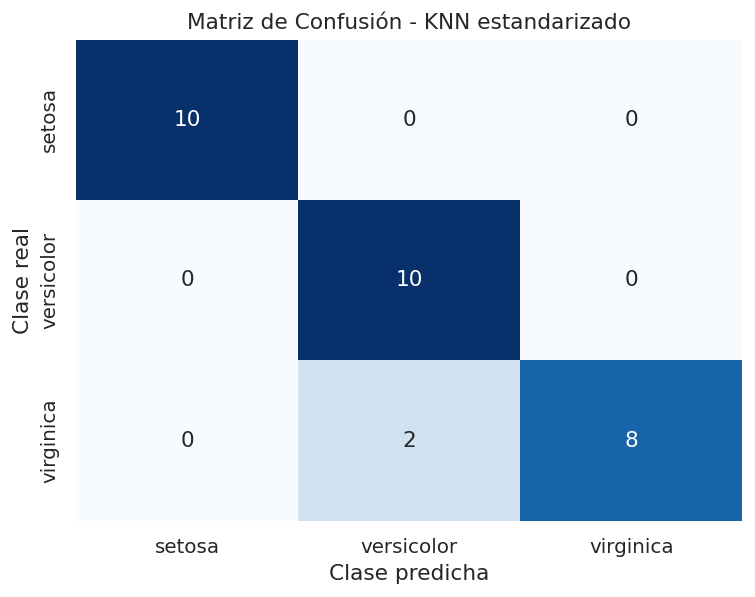

In [8]:
# KNN utiliza distancias; por ello se estandarizan los predictores.
# El escalador aprende media y desviación solo desde entrenamiento, evitando fuga de información.
scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train)
X_test_knn_scaled = scaler_knn.transform(X_test)

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)
knn_model.fit(X_train_knn_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_knn_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='macro', zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, average='macro', zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, average='macro', zero_division=0)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print(f'Accuracy KNN: {accuracy_knn:.4f}')
print(f'Precision macro KNN: {precision_knn:.4f}')
print(f'Recall macro KNN: {recall_knn:.4f}')
print(f'F1 macro KNN: {f1_knn:.4f}')
print('\nMatriz de confusión:')
print(conf_matrix_knn)
print('\nReporte de clasificación:')
print(classification_report(
    y_test, y_pred_knn, target_names=iris.target_names, digits=4, zero_division=0
))

fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(
    conf_matrix_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax
)
ax.set(title='Matriz de Confusión - KNN estandarizado',
       xlabel='Clase predicha', ylabel='Clase real')
fig.tight_layout()
fig.savefig(FIG_DIR / 'figura_2_matriz_confusion_knn.png', dpi=220, bbox_inches='tight')
plt.show()

pd.DataFrame({
    'modelo':['KNN'],
    'accuracy':[accuracy_knn],
    'precision_macro':[precision_knn],
    'recall_macro':[recall_knn],
    'f1_macro':[f1_knn],
    'n_neighbors':[5],
    'metrica_distancia':['euclidiana'],
    'escalamiento':['StandardScaler ajustado con entrenamiento']
}).to_csv(RES_DIR / 'metricas_knn.csv', index=False, encoding='utf-8-sig')


### Interpretación de resultados: KNN

KNN clasifica una observación según las clases de sus cinco vecinos más cercanos. Como el método depende de distancias, las variables se estandarizan utilizando únicamente los datos de entrenamiento.

En la ejecución reproducible, el modelo obtuvo un *accuracy* de 0,9333: clasificó correctamente 28 de las 30 flores del conjunto de prueba. Setosa y Versicolor fueron identificadas sin errores, mientras que dos observaciones de Virginica fueron clasificadas como Versicolor. La matriz de confusión permite localizar estos errores y complementa la proporción global de aciertos.

El resultado muestra que KNN es una referencia competitiva, aunque sensible a la escala y al valor del hiperparámetro `n_neighbors`. Un hiperparámetro es una configuración definida antes de entrenar; en este caso indica cuántos vecinos participan en la decisión.


## 5.2 Árbol de Decisión

Accuracy Árbol de Decisión: 0.9667

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.9000    0.9474        10
   virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



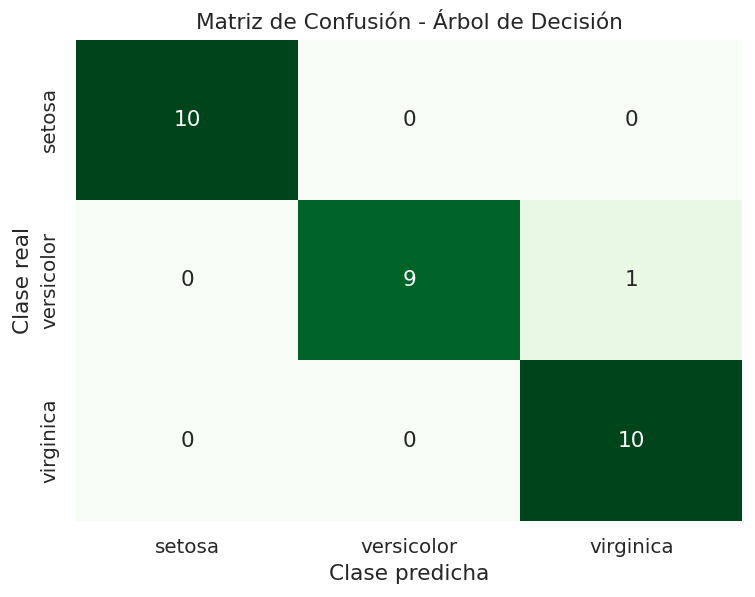

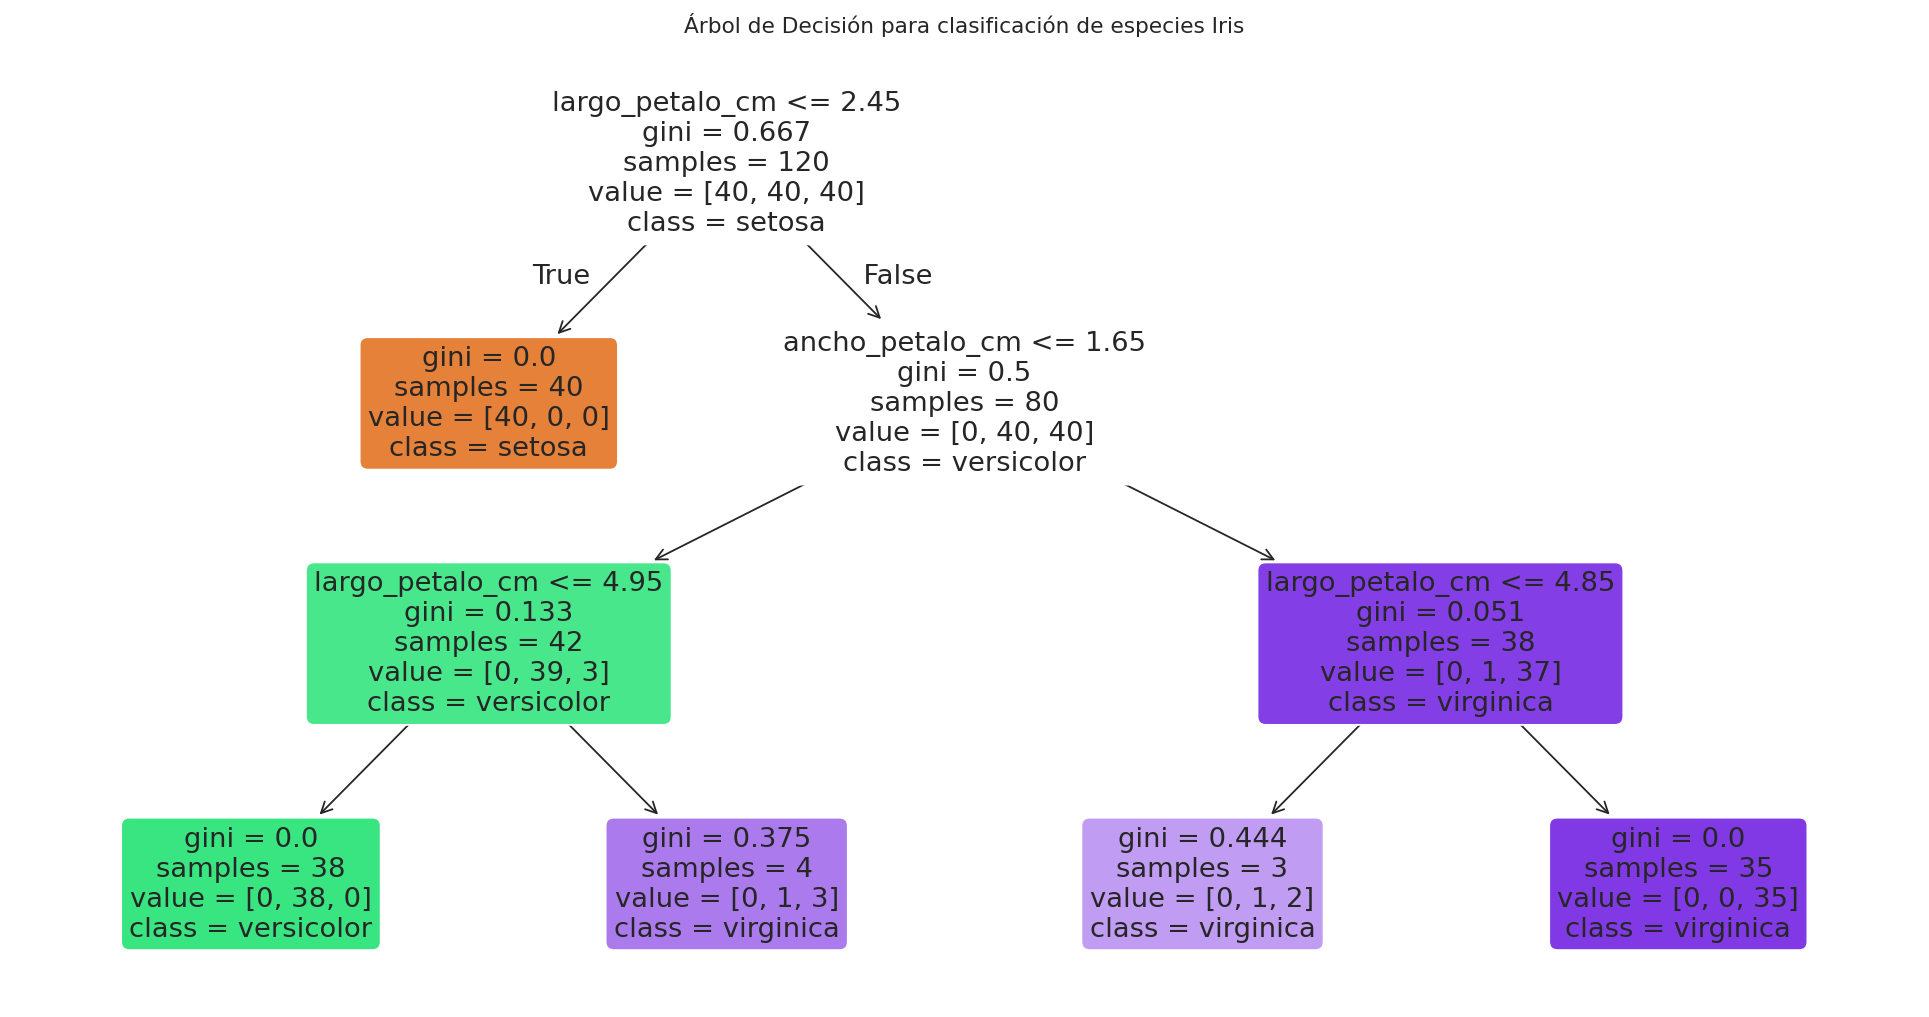

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

# Modelo Árbol de Decisión: profundidad limitada para controlar sobreajuste
tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=SEED
)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)

print(f'Accuracy Árbol de Decisión: {accuracy_tree:.4f}')
print('\nMatriz de confusión:')
print(conf_matrix_tree)
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names, digits=4))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(
    conf_matrix_tree, annot=True, fmt='d', cmap='Greens', cbar=False,
    xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax
)
ax.set(title='Matriz de Confusión - Árbol de Decisión',
       xlabel='Clase predicha', ylabel='Clase real')
fig.tight_layout()
fig.savefig(FIG_DIR / 'figura_3_matriz_confusion_arbol.png', dpi=220, bbox_inches='tight')
plt.show()

# Visualización interpretable del árbol entrenado
fig, ax = plt.subplots(figsize=(15, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    ax=ax
)
ax.set_title('Árbol de Decisión para clasificación de especies Iris')
fig.tight_layout()
fig.savefig(FIG_DIR / 'figura_4_arbol_decision.png', dpi=220, bbox_inches='tight')
plt.show()

pd.DataFrame({
    'modelo':['Árbol de Decisión'],
    'accuracy':[accuracy_tree],
    'criterion':['gini'],
    'max_depth':[3]
}).to_csv(RES_DIR / 'metricas_arbol_decision.csv', index=False, encoding='utf-8-sig')


### Interpretación de resultados: Árbol de Decisión

El Árbol de Decisión se entrenó con el criterio de impureza de Gini y una profundidad máxima de tres niveles. Esta restricción permite conservar reglas de clasificación interpretables y reduce el riesgo de sobreajuste, es decir, de que el modelo memorice particularidades del entrenamiento y pierda desempeño frente a datos nuevos.

El *accuracy* y la matriz de confusión obtenidos muestran el desempeño del modelo sobre las 30 observaciones reservadas para prueba, con diez casos de cada especie. La visualización del árbol permite identificar las variables y umbrales utilizados en las divisiones, facilitando la explicación del proceso de clasificación. Setosa suele separarse claramente mediante las dimensiones del pétalo, mientras que los posibles errores se concentran entre Versicolor y Virginica, cuyas medidas presentan mayor solapamiento.

Aunque el resultado se obtenga sobre una partición estratificada y reproducible, no debe interpretarse como una garantía de desempeño perfecto en datos nuevos. En una fase posterior conviene complementar esta evaluación con validación cruzada y ajuste de hiperparámetros —configuraciones definidas antes de entrenar— como `max_depth`, `min_samples_split` y `min_samples_leaf`.


## 5.3 Support Vector Machine (SVM)

Support Vector Machine busca una frontera de decisión que maximice el margen entre clases. Se utiliza un kernel radial (`rbf`) para capturar relaciones no lineales entre las medidas morfológicas y la especie. Debido a que SVM es sensible a la escala de las variables, el escalador se ajusta exclusivamente con el conjunto de entrenamiento y luego se aplica al conjunto de prueba, evitando fuga de información.


Accuracy SVM: 0.9667

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.9000    0.9474        10
   virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



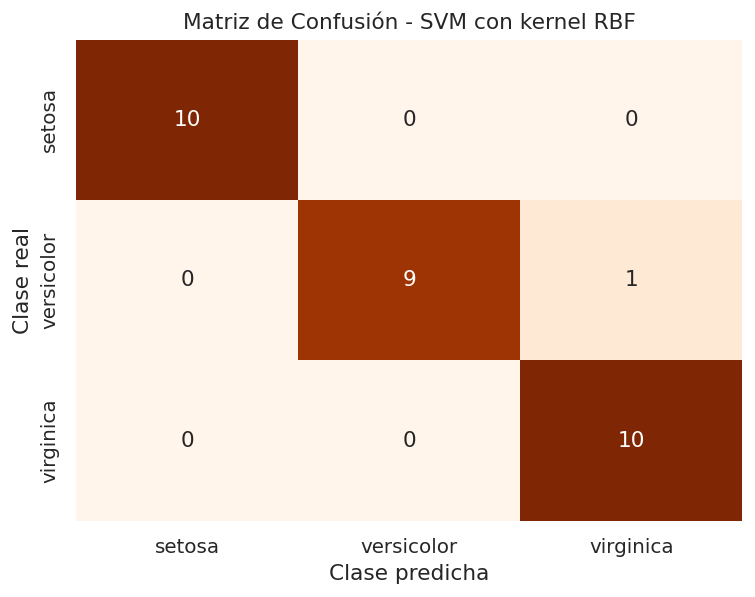

In [10]:
# Escalamiento ajustado únicamente con datos de entrenamiento
scaler_svm = StandardScaler()
X_train_scaled = scaler_svm.fit_transform(X_train)
X_test_scaled = scaler_svm.transform(X_test)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=SEED
)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print(f'Accuracy SVM: {accuracy_svm:.4f}')
print('\nMatriz de confusión:')
print(conf_matrix_svm)
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_svm, target_names=iris.target_names, digits=4))

fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(
    conf_matrix_svm, annot=True, fmt='d', cmap='Oranges', cbar=False,
    xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax
)
ax.set(title='Matriz de Confusión - SVM con kernel RBF',
       xlabel='Clase predicha', ylabel='Clase real')
fig.tight_layout()
fig.savefig(FIG_DIR / 'figura_5_matriz_confusion_svm.png', dpi=220, bbox_inches='tight')
plt.show()

pd.DataFrame({
    'modelo':['SVM'],
    'accuracy':[accuracy_svm],
    'kernel':['rbf'],
    'C':[1.0],
    'gamma':['scale']
}).to_csv(RES_DIR / 'metricas_svm.csv', index=False, encoding='utf-8-sig')


### Interpretación de resultados: SVM

El modelo SVM se entrenó con kernel RBF, `C=1.0` y `gamma='scale'`, utilizando variables estandarizadas. El escalamiento es metodológicamente necesario porque la posición de la frontera y las distancias en el espacio de características pueden verse dominadas por variables con rangos numéricos mayores.

El *accuracy* resume la proporción total de clasificaciones correctas, mientras que la matriz de confusión permite verificar el comportamiento específico para Setosa, Versicolor y Virginica. La separación de Setosa suele ser directa; los errores, cuando aparecen, tienden a producirse entre Versicolor y Virginica debido a su mayor similitud morfológica.

Esta evaluación es preliminar y utiliza la misma partición estratificada aplicada a KNN y al Árbol de Decisión, lo que asegura una comparación consistente. La selección preliminar del modelo se realiza en las secciones siguientes después de incorporar Naïve Bayes y comparar todos los resultados mediante métricas comunes.


## 5.4 Naïve Bayes Gaussiano

Naïve Bayes es un clasificador probabilístico basado en el teorema de Bayes. Su supuesto simplificador es que las variables predictoras son condicionalmente independientes dentro de cada clase. Como las cuatro medidas de Iris son continuas, se utiliza la variante gaussiana, que representa cada variable mediante una distribución normal por especie.

El modelo es rápido, no requiere escalamiento para esta aplicación y entrega una referencia útil frente a métodos basados en distancia, reglas y márgenes.


Accuracy Naïve Bayes: 0.9667
Precision macro Naïve Bayes: 0.9697
Recall macro Naïve Bayes: 0.9667
F1 macro Naïve Bayes: 0.9666

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.9000    0.9474        10
   virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



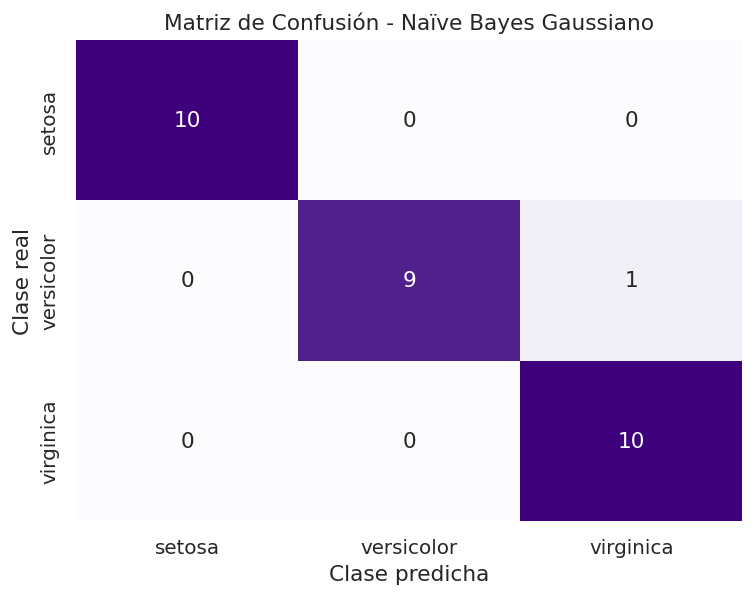

In [11]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='macro', zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, average='macro', zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, average='macro', zero_division=0)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

print(f'Accuracy Naïve Bayes: {accuracy_nb:.4f}')
print(f'Precision macro Naïve Bayes: {precision_nb:.4f}')
print(f'Recall macro Naïve Bayes: {recall_nb:.4f}')
print(f'F1 macro Naïve Bayes: {f1_nb:.4f}')
print('\nMatriz de confusión:')
print(conf_matrix_nb)
print('\nReporte de clasificación:')
print(classification_report(
    y_test, y_pred_nb, target_names=iris.target_names, digits=4, zero_division=0
))

fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(
    conf_matrix_nb, annot=True, fmt='d', cmap='Purples', cbar=False,
    xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax
)
ax.set(title='Matriz de Confusión - Naïve Bayes Gaussiano',
       xlabel='Clase predicha', ylabel='Clase real')
fig.tight_layout()
fig.savefig(FIG_DIR / 'figura_6_matriz_confusion_naive_bayes.png', dpi=220, bbox_inches='tight')
plt.show()

pd.DataFrame({
    'modelo':['Naïve Bayes Gaussiano'],
    'accuracy':[accuracy_nb],
    'precision_macro':[precision_nb],
    'recall_macro':[recall_nb],
    'f1_macro':[f1_nb],
    'var_smoothing':[nb_model.var_smoothing]
}).to_csv(RES_DIR / 'metricas_naive_bayes.csv', index=False, encoding='utf-8-sig')


### Interpretación de resultados: Naïve Bayes

Naïve Bayes obtuvo un *accuracy* de 0,9667, equivalente a 29 clasificaciones correctas de 30. Setosa y Virginica fueron clasificadas correctamente; el único error correspondió a una flor Versicolor clasificada como Virginica.

El desempeño es equivalente al obtenido por el Árbol de Decisión y SVM en esta partición. Su principal fortaleza es la simplicidad y el bajo costo computacional. Su limitación es el supuesto de independencia entre predictores, que no se cumple estrictamente en Iris porque algunas medidas presentan correlaciones altas.


# 6. Comparación preliminar de modelos

Una métrica es una medida numérica utilizada para evaluar el modelo. En esta comparación se emplean:

- **Accuracy:** proporción total de predicciones correctas.
- **Precision macro:** promedio de la precisión calculada por separado para cada especie; responde cuántas predicciones de una clase fueron correctas.
- **Recall macro:** promedio de la capacidad para encontrar los casos reales de cada especie.
- **F1 macro:** equilibrio entre precision y recall, dando el mismo peso a las tres especies.
- **Brecha entrenamiento-prueba:** diferencia absoluta entre el accuracy de entrenamiento y prueba; una brecha grande puede advertir problemas de generalización.

Todos los modelos se comparan sobre las mismas 30 observaciones de prueba. Esta condición evita atribuir diferencias de desempeño a particiones distintas.


Modelos con mayor F1 macro: ['SVM RBF', 'Naïve Bayes', 'Árbol de Decisión']


              modelo  ...                                    hiperparametros
0            SVM RBF  ...     kernel=rbf; C=1.0; gamma=scale; StandardScaler
1        Naïve Bayes  ...                    GaussianNB; var_smoothing=1e-09
2  Árbol de Decisión  ...                        criterion=gini; max_depth=3
3                KNN  ...  n_neighbors=5; distancia euclidiana; StandardS...

[4 rows x 9 columns]

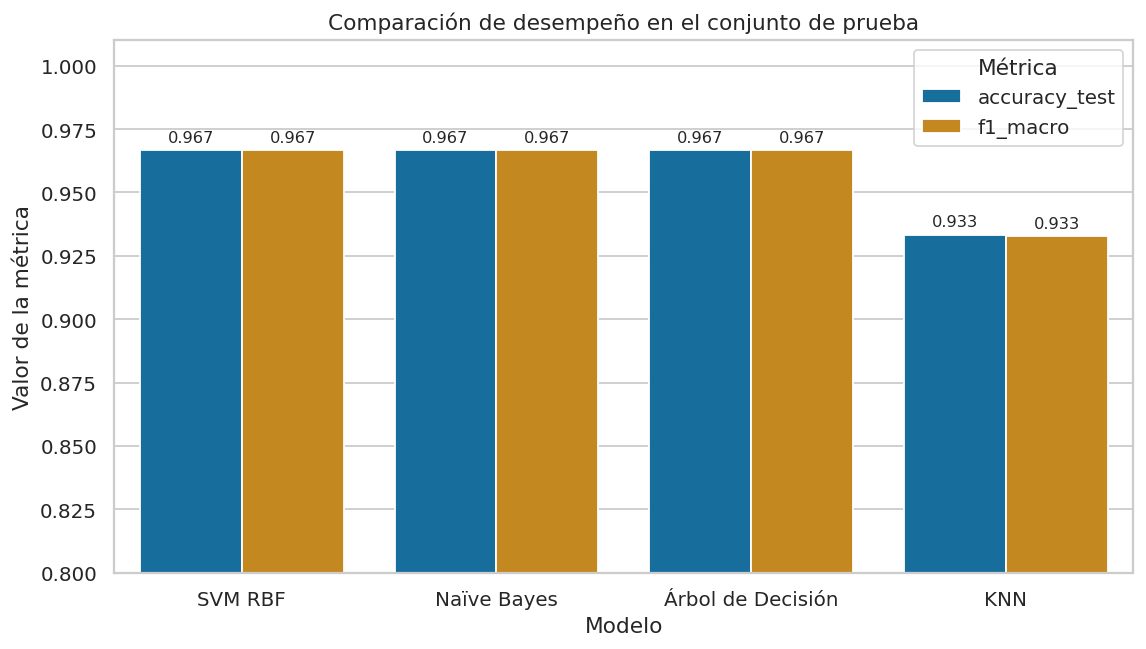

In [12]:
modelos_comparacion = [
    {
        'modelo': 'KNN',
        'modelo_objeto': knn_model,
        'X_train_eval': X_train_knn_scaled,
        'y_pred_test': y_pred_knn,
        'hiperparametros': 'n_neighbors=5; distancia euclidiana; StandardScaler'
    },
    {
        'modelo': 'Árbol de Decisión',
        'modelo_objeto': tree_model,
        'X_train_eval': X_train,
        'y_pred_test': y_pred_tree,
        'hiperparametros': 'criterion=gini; max_depth=3'
    },
    {
        'modelo': 'SVM RBF',
        'modelo_objeto': svm_model,
        'X_train_eval': X_train_scaled,
        'y_pred_test': y_pred_svm,
        'hiperparametros': "kernel=rbf; C=1.0; gamma=scale; StandardScaler"
    },
    {
        'modelo': 'Naïve Bayes',
        'modelo_objeto': nb_model,
        'X_train_eval': X_train,
        'y_pred_test': y_pred_nb,
        'hiperparametros': f'GaussianNB; var_smoothing={nb_model.var_smoothing}'
    }
]

filas_metricas = []
for item in modelos_comparacion:
    y_pred_train = item['modelo_objeto'].predict(item['X_train_eval'])
    y_pred_test = item['y_pred_test']
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    filas_metricas.append({
        'modelo': item['modelo'],
        'accuracy_train': acc_train,
        'accuracy_test': acc_test,
        'precision_macro': precision_score(y_test, y_pred_test, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred_test, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred_test, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred_test, average='weighted', zero_division=0),
        'brecha_abs_train_test': abs(acc_train - acc_test),
        'hiperparametros': item['hiperparametros']
    })

comparacion_modelos = pd.DataFrame(filas_metricas).sort_values(
    ['f1_macro', 'brecha_abs_train_test'], ascending=[False, True]
).reset_index(drop=True)

display(comparacion_modelos.round(4))
comparacion_modelos.to_csv(
    RES_DIR / 'comparacion_modelos.csv', index=False, encoding='utf-8-sig'
)

# Los archivos individuales quedan con las mismas métricas para facilitar su auditoría.
nombres_archivo = {
    'KNN': 'metricas_knn.csv',
    'Árbol de Decisión': 'metricas_arbol_decision.csv',
    'SVM RBF': 'metricas_svm.csv',
    'Naïve Bayes': 'metricas_naive_bayes.csv'
}
for modelo, archivo in nombres_archivo.items():
    comparacion_modelos.loc[comparacion_modelos['modelo'] == modelo].to_csv(
        RES_DIR / archivo, index=False, encoding='utf-8-sig'
    )

grafico_metricas = comparacion_modelos.melt(
    id_vars='modelo',
    value_vars=['accuracy_test', 'f1_macro'],
    var_name='metrica',
    value_name='valor'
)
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.barplot(data=grafico_metricas, x='modelo', y='valor', hue='metrica', ax=ax)
ax.set(
    title='Comparación de desempeño en el conjunto de prueba',
    xlabel='Modelo', ylabel='Valor de la métrica', ylim=(0.80, 1.01)
)
ax.legend(title='Métrica')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'figura_7_comparacion_modelos.png', dpi=220, bbox_inches='tight')
plt.show()

mejor_f1 = comparacion_modelos['f1_macro'].max()
empatados = comparacion_modelos.loc[
    np.isclose(comparacion_modelos['f1_macro'], mejor_f1), 'modelo'
].tolist()
print('Modelos con mayor F1 macro:', empatados)


## 6.1 Interpretación y selección preliminar

Árbol de Decisión, SVM y Naïve Bayes alcanzaron el mismo desempeño de prueba: *accuracy* 0,9667 y F1 macro 0,9666. KNN estandarizado obtuvo *accuracy* 0,9333 y F1 macro 0,9327. Por lo tanto, esta ejecución no permite declarar un ganador únicamente por desempeño entre los tres modelos empatados.

Para la continuidad del proyecto se selecciona preliminarmente el **Árbol de Decisión** como alternativa principal: conserva el mejor nivel de desempeño observado y permite explicar sus reglas mediante variables y umbrales visibles. SVM ofrece una frontera robusta, pero es menos interpretable; Naïve Bayes es simple y eficiente, aunque su supuesto de independencia es restrictivo; KNN es intuitivo, pero sensible a la escala y a la elección del número de vecinos.

La selección es preliminar porque se basa en una sola partición de 30 observaciones de prueba. En el informe final del proyecto conviene confirmar la estabilidad mediante validación cruzada y ajuste de hiperparámetros sin utilizar el conjunto de prueba para tomar decisiones de entrenamiento.


# 7. Validaciones y cierre de la Formativa 3

Las validaciones siguientes comprueban que existen cuatro modelos, que todas las métricas se encuentran en rangos válidos y que los artefactos exigidos fueron creados. Si alguna condición no se cumple, la celda se detiene con un error visible.


In [13]:
modelos_esperados = {'KNN', 'Árbol de Decisión', 'SVM RBF', 'Naïve Bayes'}
columnas_metricas = [
    'accuracy_train', 'accuracy_test', 'precision_macro', 'recall_macro',
    'f1_macro', 'f1_weighted', 'brecha_abs_train_test'
]

assert set(comparacion_modelos['modelo']) == modelos_esperados
assert comparacion_modelos[columnas_metricas].notna().all().all()
assert comparacion_modelos[columnas_metricas].apply(lambda s: s.between(0, 1).all()).all()
assert all(len(pred) == len(y_test) for pred in [y_pred_knn, y_pred_tree, y_pred_svm, y_pred_nb])

artefactos_esperados = [
    FIG_DIR / 'figura_1_relacion_petalo.png',
    FIG_DIR / 'figura_2_matriz_confusion_knn.png',
    FIG_DIR / 'figura_3_matriz_confusion_arbol.png',
    FIG_DIR / 'figura_4_arbol_decision.png',
    FIG_DIR / 'figura_5_matriz_confusion_svm.png',
    FIG_DIR / 'figura_6_matriz_confusion_naive_bayes.png',
    FIG_DIR / 'figura_7_comparacion_modelos.png',
    RES_DIR / 'resumen_por_especie.csv',
    RES_DIR / 'metricas_knn.csv',
    RES_DIR / 'metricas_arbol_decision.csv',
    RES_DIR / 'metricas_svm.csv',
    RES_DIR / 'metricas_naive_bayes.csv',
    RES_DIR / 'comparacion_modelos.csv'
]

faltantes = [str(ruta) for ruta in artefactos_esperados if not ruta.exists()]
assert not faltantes, f'Artefactos faltantes: {faltantes}'

print('✅ Formativa 3 ejecutada y validada sin errores.')
print(f'✅ Modelos comparados: {len(comparacion_modelos)}')
print(f'✅ Artefactos verificados: {len(artefactos_esperados)}')


✅ Formativa 3 ejecutada y validada sin errores.
✅ Modelos comparados: 4
✅ Artefactos verificados: 13


## Continuidad hacia el informe final del proyecto

La Formativa 3 queda cerrada como avance técnico: el notebook contiene cuatro clasificadores, métricas comparables, matrices de confusión, archivos de resultados, validaciones automáticas y una selección preliminar fundamentada.

La evaluación sumativa posterior podrá comenzar desde esta versión y ampliar el análisis según la pauta oficial de Canvas. Antes de desarrollar esa evaluación se deberán confirmar su rúbrica, formato de informe, evidencias requeridas y condiciones de entrega.
